In [1]:
#%config InlineBackend.figure_formats=['svg']
from src.Utils import plot_traces, save_results, get_means
from src.Dataset import dataset_TES
#from src.LoadAutoencoder import load_autoencoder
from src.ExistingAlgorithms import max_value, area, sklearn_available
from src.GaussianMixture import gaussian_mixture

from sklearn.decomposition import PCA, KernelPCA, NMF
from sklearn.manifold import Isomap, TSNE

import umap

import numpy as np
import matplotlib.pyplot as plt

2024-07-12 11:41:20.806079: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2024-07-12 11:41:20.806177: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


In [2]:
# Remove outlier cluster
#gm.cluster_means = np.delete(gm.cluster_means, 4,0)
#gm.cluster_covariances = np.delete(gm.cluster_covariances, 4,0)
#gm.cluster_weights = np.delete(gm.cluster_weights, 4,0)

In [3]:
# Add point 
#mean_ = np.append(get_means(name_method, path = path_results), [get_means(name_method, path = path_results)[10]+0.01], axis=0)
#mean_

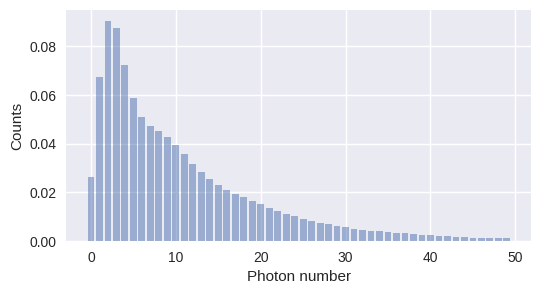

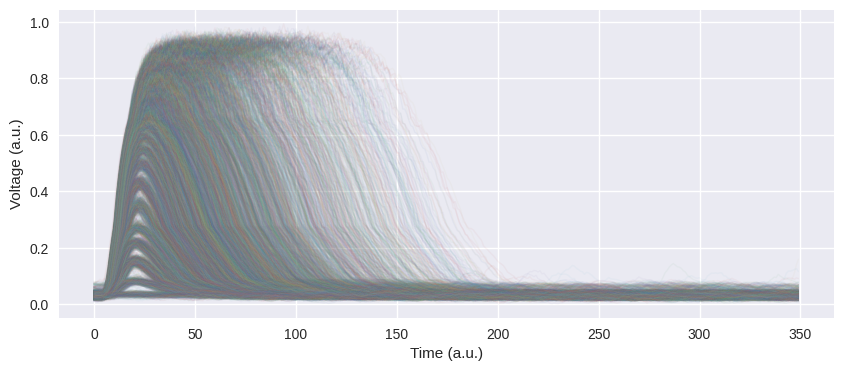

(57020, 350)

In [4]:
weights = [1.00000000e+00, 8.67567149e-01, 5.11893733e-01, 4.64791825e-01, 
           1.95257413e-01, 3.48166360e-01,1.24623185e-13, 3.89968505e-14, 3.60043421e-01]

weights = [0.07051088775512344, 0.21031270568057314, 0.38445365365055423, 0.6780434874139336, 0.6001082447024342, 0.9999999999999999, 0.629191619746778, 1.1954682934335052e-17, 0.9999999799606453, 0.9999999999649708]


path_save = 'src/Results TES (Thermal)/Low Dimension'
path_results = 'src/Results TES (Thermal)'

data_train, data_test, expected_prob = dataset_TES(weights = weights,
                                                path_random_index = r'/home/nicolasdc/Documents/publish/src/Results TES (Thermal)/randomIndexThermal.npy',
                                                signal_size = 8192,
                                                interval = [0,350],#270],
                                                order_dB = False,
                                                normalize = True,
                                                plot_expected = True,
                                                plot_traces = True,
                                                n_photon_number = 50)
data_train.shape

### PIKA

In [5]:
# pk = PIKA(n_iter = 100, n_epoch = 10, N_mean = [2, 3])
# pk.run_PIKA(X_test, plot=True)

### Max Value

In [6]:
X_l_MAX = max_value(data_test, filter=True)

/home/nicolasdc/anaconda3/envs/ML/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


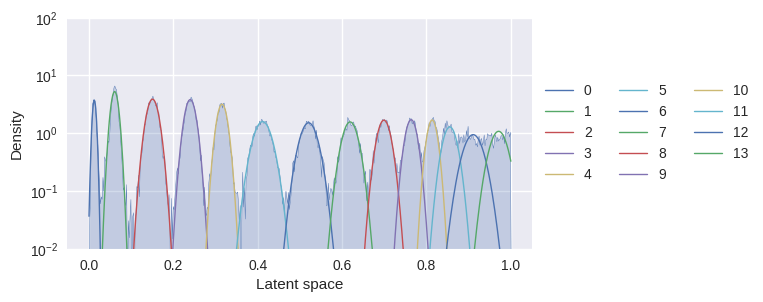

In [7]:
name_method = 'MAX'
condition = X_l_MAX[:,0] < 0.8
gm = gaussian_mixture(X_l_MAX[condition], 
                    data_test[condition],
                    number_cluster = 14,
                    means_init = get_means(name_method, path = path_results),
                    cluster_iter = 10,
                    info_sweep = 0,
                    plot_sweep = True,
                    dpi = 100)

gm.plot_density(bw_adjust = 0.01,)
#gm.plot_cluster(plot_kde = False)
#gm.plot_traces()
#gm.plot_traces_average()

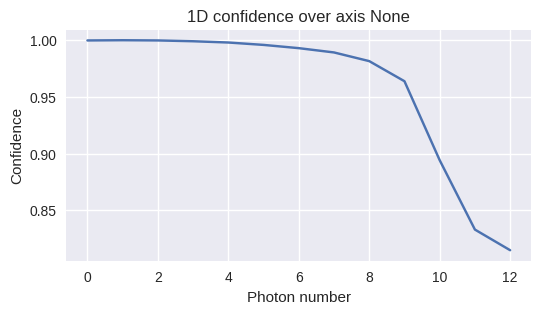

In [8]:
gm.plot_confidence_1d(expected_prob = expected_prob)
gm.plot_trustworthiness()
save_results(gm = gm, name_method = name_method, path = path_results)

### Area

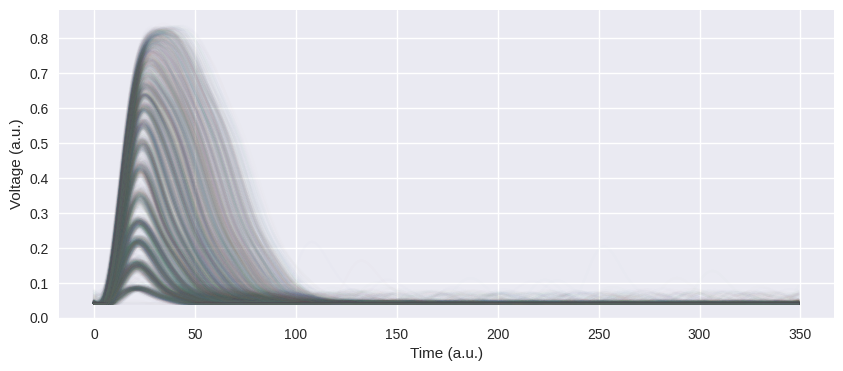

In [ ]:
condition = np.logical_and(np.max(data_test,axis=1) > 0.08, np.max(data_test,axis=1) < 0.85)
X_l_AREA  = area(data_test[condition], filter = True, plot_filter = True, threshold = 0.04, cutoff = 0.05)

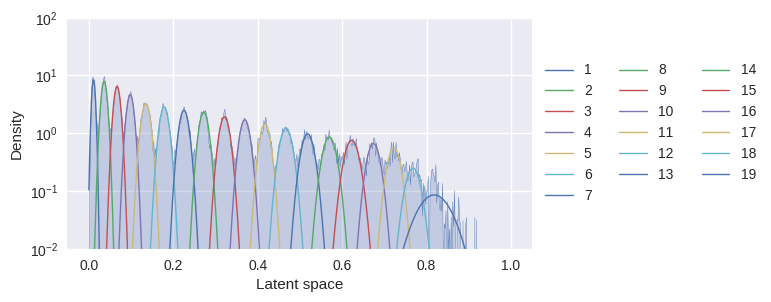

In [ ]:
name_method = 'AREA'
gm = gaussian_mixture(X_l_AREA,
                      data_test[condition],
                      number_cluster = 19,
                      cluster_iter = 5,
                      means_init = get_means(name_method, path_results),
                      tol = 1e-4,
                      info_sweep = 0,
                      plot_sweep = True,
                      label_shift = 1)

gm.plot_density(bw_adjust = 0.01)
# gm.plot_cluster(plot_kde = True, bw_adjust = 1)
# gm.plot_traces()
# gm.plot_traces_average()

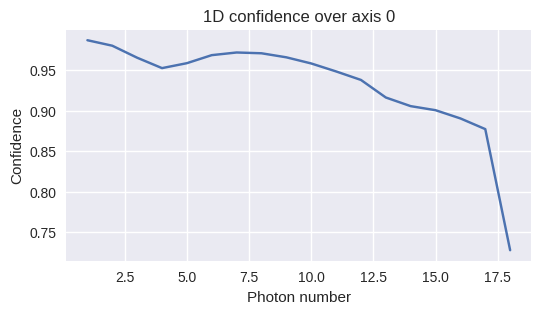

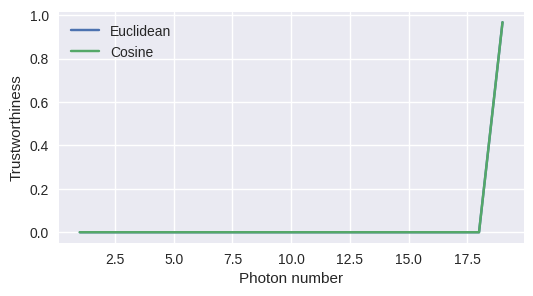

In [ ]:
gm.plot_confidence_1d(expected_prob = expected_prob[1:], axis = 0) 
gm.plot_trustworthiness()
save_results(gm = gm, name_method = name_method, path = path_results)

### Principal Component Analysis (PCA)

In [ ]:
X_l_PCA = sklearn_available(data_train, data_test, path_save, PCA, n_components=2) 

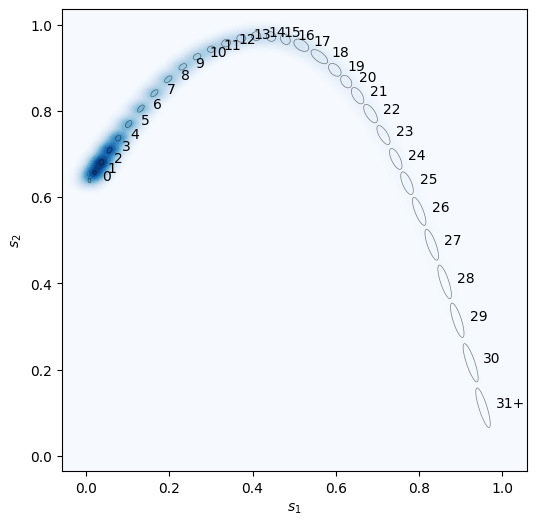

In [ ]:
name_method = 'PCA 2D'
gm = gaussian_mixture(X_l_PCA,
                      data_test,
                      number_cluster = 32,
                      cluster_iter = 5,
                      means_init = get_means(name_method, path_results),
                      tol = 1e-3,
                      info_sweep = 0,
                      plot_sweep = True)
#gm.cmap  = 'Blues'
gm.plot_density(bw_adjust=0.1)
#gm.plot_cluster(plot_kde = True, bw_adjust = 0.1)
#gm.plot_traces()
#gm.plot_traces_average()

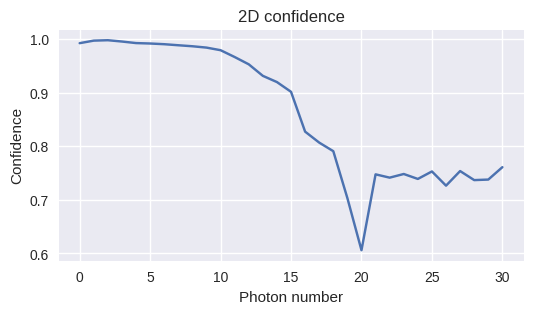

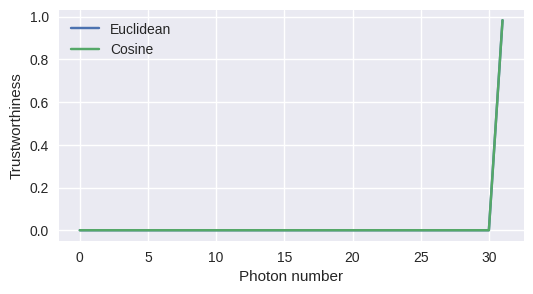

In [ ]:
gm.plot_confidence_2d(expected_prob = expected_prob)
gm.plot_trustworthiness()
save_results(gm = gm, name_method = name_method, path = path_results)

In [ ]:
X_l_PCA = sklearn_available(data_train, data_test, path_save, PCA, n_components=1) 

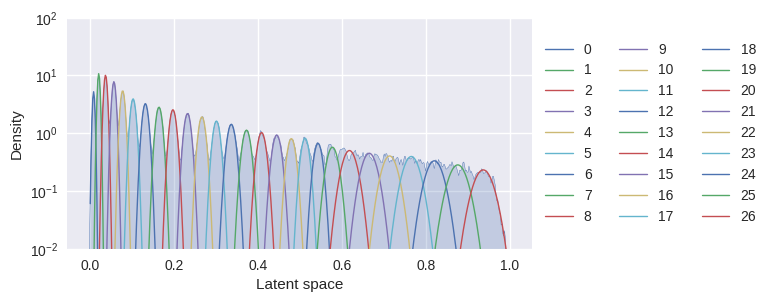

In [ ]:
name_method = 'PCA 1D'
gm = gaussian_mixture(X_l_PCA,
                      data_test,
                      number_cluster = 27,
                      cluster_iter = 5,
                      means_init = get_means(name_method, path_results),
                      tol = 1e-3,
                      info_sweep = 0,
                      plot_sweep = True)
#gm.cmap  = 'Blues'
gm.plot_density(bw_adjust=0.05)
#gm.plot_cluster(plot_kde = True, bw_adjust = 0.1)
#gm.plot_traces()
#gm.plot_traces_average()

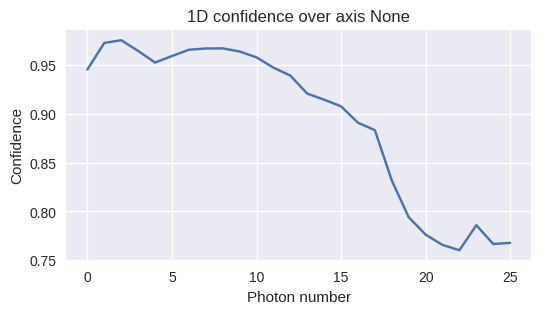

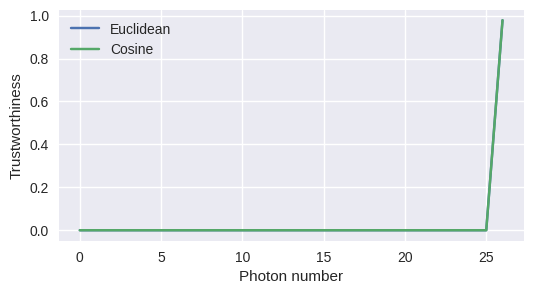

In [ ]:
gm.plot_confidence_1d(expected_prob = expected_prob)
gm.plot_trustworthiness()
save_results(gm = gm, name_method = name_method, path = path_results)

### Kernel PCA (Polynomial)

In [ ]:
#X_l_KPCA_P = sklearn_available(data_train, data_test, path_save, KernelPCA,n_components=2, kernel="poly", gamma=1, degree = 2)

In [ ]:
#name_method = 'KPCA Pol'
#gm = gaussian_mixture(X_l_KPCA_P,
#                      data_test,
#                      number_cluster = 27,
#                      cluster_iter = 20,
#                      means_init = None,#get_means(name_method, path_results),
#                      tol = 1e-3,
#                      info_sweep = 1,
#                      plot_sweep = True)

#gm.plot_density(bw_adjust = 0.1,
#                bw_adjust_x = 0.05,
#                bw_adjust_y = 0.05)
#gm.plot_cluster(plot_kde = True, bw_adjust = 0.1)
#gm.plot_traces()
#gm.plot_traces_average()

In [ ]:
#gm.plot_confidence_1d(axis = 0) 
#gm.plot_confidence_2d()
#gm.plot_trustworthiness()
#save_results(gm = gm, name_method = name_method, path = path_results)

### Kernel PCA (Radial basis function)

In [ ]:
X_l_KPCA_RBF = sklearn_available(data_train, data_test, path_save, KernelPCA, n_components = 2, kernel="rbf", gamma = 0.5) 

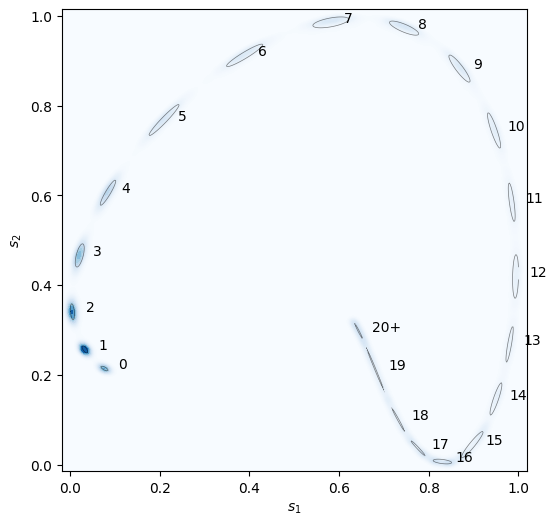

In [ ]:
name_method = 'KPCA RBF'
gm = gaussian_mixture(X_l_KPCA_RBF,
                      data_test,
                      number_cluster = 21,
                      cluster_iter = 5,
                      tol = 1e-3,
                      means_init = get_means(name_method, path_results),
                      info_sweep = 1,
                      plot_sweep = True)

gm.plot_density(bw_adjust=0.1)
#gm.plot_cluster(plot_kde = True, bw_adjust = 0.1)
#gm.plot_traces()
#gm.plot_traces_average()

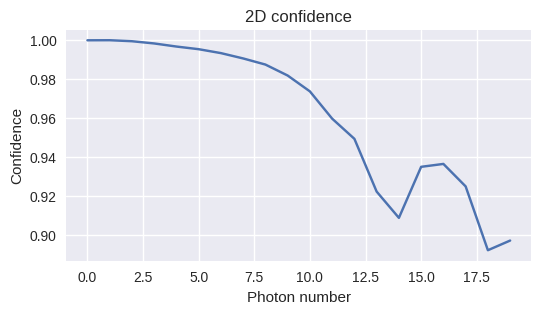

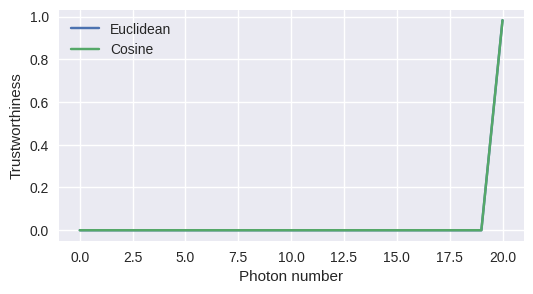

In [ ]:
#gm.plot_confidence_1d(axis = 0) 
gm.plot_confidence_2d(expected_prob = expected_prob)
gm.plot_trustworthiness()
save_results(gm = gm, name_method = name_method, path = path_results)

### Kernel PCA (Sigmoid)

In [ ]:
X_l_KPCA_S = sklearn_available(data_train, data_test, path_save, KernelPCA,n_components=2,kernel="sigmoid",gamma=0.01) 

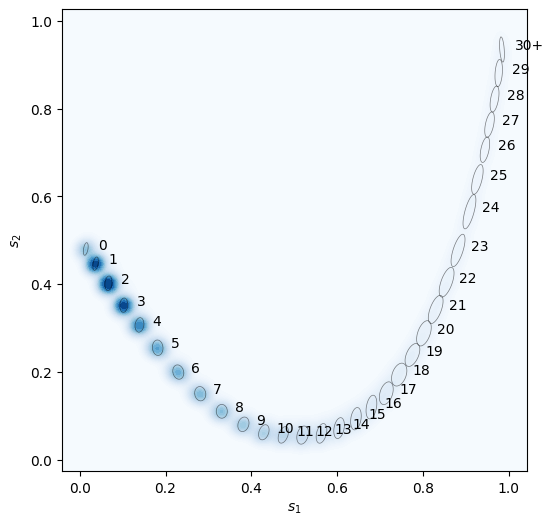

In [ ]:
name_method = 'KPCA Sig'
gm = gaussian_mixture(X_l_KPCA_S,
                      data_test,
                      number_cluster = 31,
                      cluster_iter = 5,
                      tol = 1e-4,
                      means_init = get_means(name_method, path_results),
                      info_sweep = 0,
                      plot_sweep = True)

gm.plot_density(bw_adjust=0.3)
# gm.plot_cluster(plot_kde = True, bw_adjust = 0.1)
# gm.plot_traces()
# gm.plot_traces_average()

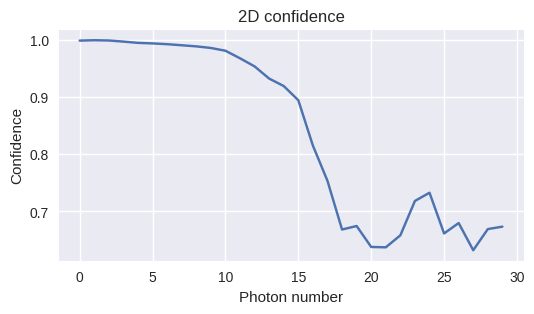

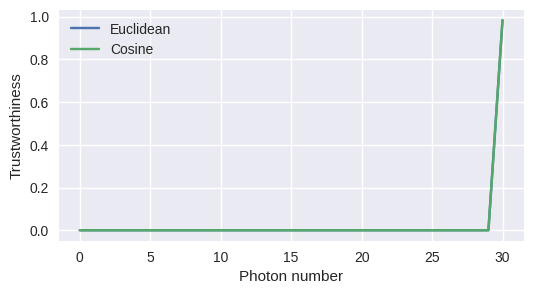

In [ ]:
#gm.plot_confidence_1d(axis = 0) 
gm.plot_confidence_2d(expected_prob = expected_prob)
gm.plot_trustworthiness()
save_results(gm = gm, name_method = name_method, path = path_results)

### Kernel PCA (Cosine)

In [ ]:
X_l_KPCA_C = sklearn_available(data_train, data_test, path_save, KernelPCA,n_components=2,kernel="cosine",gamma=0.01) 

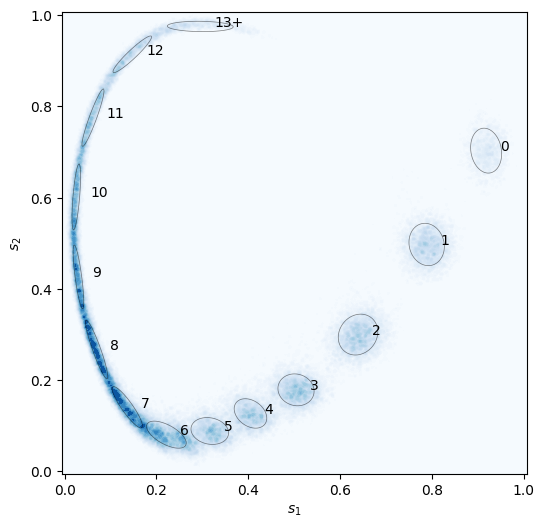

In [ ]:
name_method = 'KPCA Cos'
gm = gaussian_mixture(X_l_KPCA_C,
                      data_test,
                      number_cluster = 14,
                      cluster_iter = 5,
                      tol = 1e-4,
                      means_init = get_means(name_method, path_results),
                      info_sweep = 0,
                      plot_sweep = True)

gm.plot_density(bw_adjust=0.05)
# gm.plot_cluster(plot_kde = True, bw_adjust = 0.1)
# gm.plot_traces()
# gm.plot_traces_average()

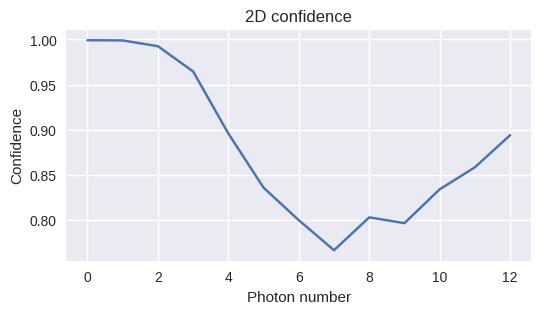

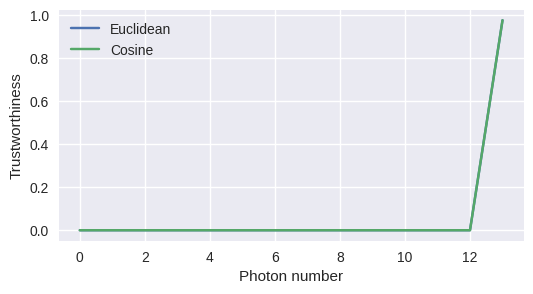

In [ ]:
#gm.plot_confidence_1d(axis = 0) 
gm.plot_confidence_2d(expected_prob = expected_prob)
gm.plot_trustworthiness()
save_results(gm = gm, name_method = name_method, path = path_results)

### t-distributed Stochastic Neighbor Embedding (t-SNE)

In [ ]:
# n_samples = data_test.shape[0]
# perplexity = np.linspace(5, 4*np.sqrt(n_samples), 10)
# divergence = []

# for i in perplexity:
#     model = TSNE(n_components=1, init="pca", perplexity=i)
#     reduced = model.fit_transform(data_test)
#     divergence.append(model.kl_divergence_)

# with plt.style.context("seaborn-v0_8"):
#     plt.figure(figsize = (10,4))
#     plt.plot(perplexity, divergence)
#     plt.ylabel('KL divergence')
#     plt.xlabel('Perplexity')
#     plt.show()

In [ ]:
X_l_tSNE = sklearn_available(data_train, data_test, path_save, TSNE, n_components=2, perplexity = 450)

Method does not have a transform function


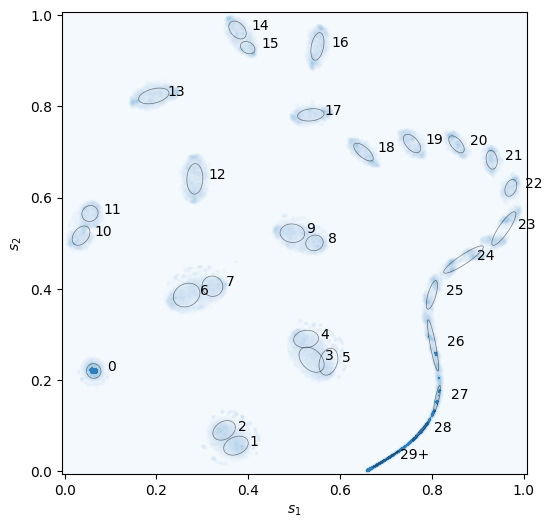

In [ ]:
name_method = 'tSNE 2D'
gm = gaussian_mixture(X_l_tSNE,
                      data_test,
                      number_cluster = 30,
                      cluster_iter = 5,
                      tol = 1e-3,
                      means_init = get_means(name_method, path_results),
                      info_sweep = 0,
                      plot_sweep = True)

gm.plot_density(bw_adjust=0.05,
                plot_gaussians=True)
#gm.plot_cluster(plot_kde = True, bw_adjust = 0.1)
#gm.plot_traces()
#gm.plot_traces_average()

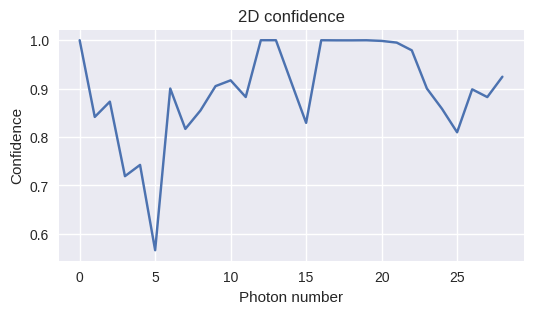

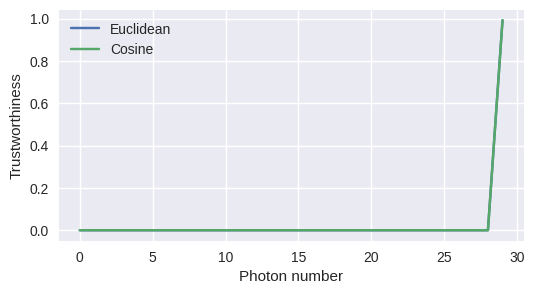

In [ ]:
#gm.plot_confidence_1d(axis = 0)
gm.plot_confidence_2d(expected_prob=expected_prob) 
gm.plot_trustworthiness()
save_results(gm = gm, name_method = name_method, path = path_results)

In [ ]:
X_l_tSNE = sklearn_available(data_train, data_test, path_save, TSNE, n_components=1, perplexity = 450)

Method does not have a transform function


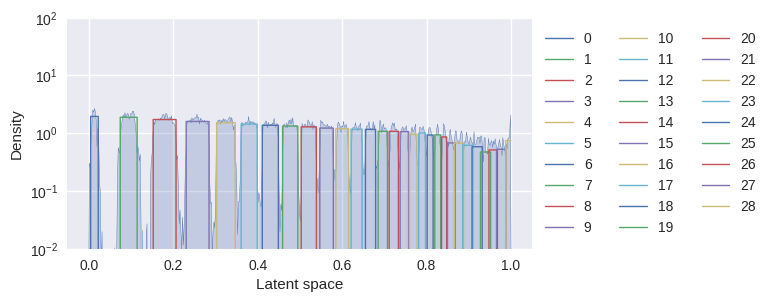

In [ ]:
name_method = 'tSNE 1D'
gm = gaussian_mixture(X_l_tSNE,
                      data_test,
                      number_cluster = 29,
                      cluster_iter = 5,
                      tol = 1e-3,
                      means_init = get_means(name_method, path_results),
                      info_sweep = 0,
                      plot_sweep = True)

gm.plot_density(bw_adjust=0.01,
                plot_gaussians=False,
                plot_uniform=True)
#gm.plot_cluster(plot_kde = True, bw_adjust = 0.1)
#gm.plot_traces()
#gm.plot_traces_average()

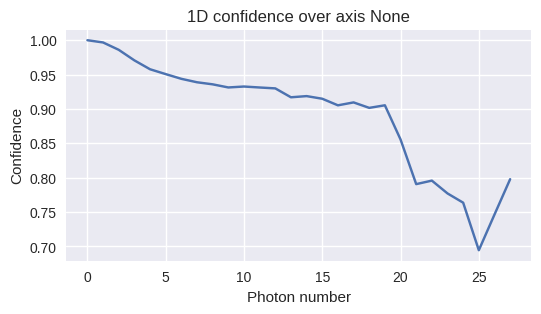

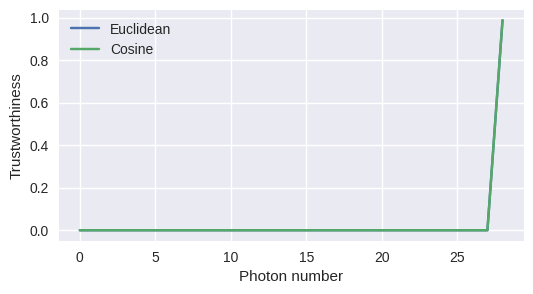

In [ ]:
gm.plot_confidence_1d(expected_prob=expected_prob) 
gm.plot_trustworthiness()
save_results(gm = gm, name_method = name_method, path = path_results)

### UMAP

In [ ]:
X_l_UMAP = sklearn_available(data_train, data_test, path_save, umap.UMAP,n_components=2, n_neighbors=15)

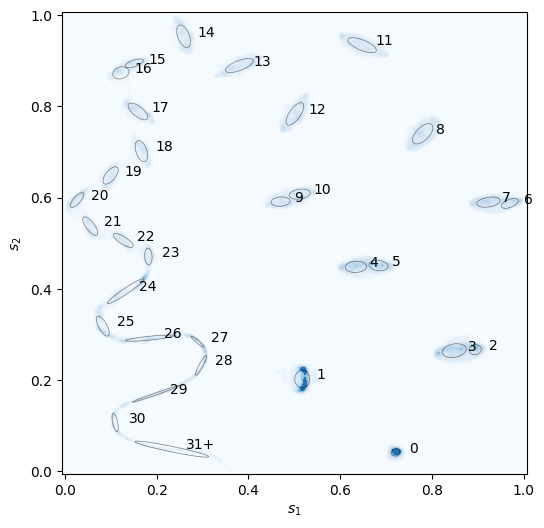

In [ ]:
name_method = 'UMAP 2D'
gm = gaussian_mixture(X_low = X_l_UMAP,
                      X_high = data_test,
                      number_cluster = 32,
                      cluster_iter = 5,
                      means_init = None,#get_means(name_method, path = path_results),
                      tol = 1e-3,
                      info_sweep = 0,
                      plot_sweep = True)

gm.plot_density(bw_adjust=0.05)
#gm.plot_cluster(plot_kde = False, bw_adjust = 0.1)
#gm.plot_traces()
#gm.plot_traces_average()

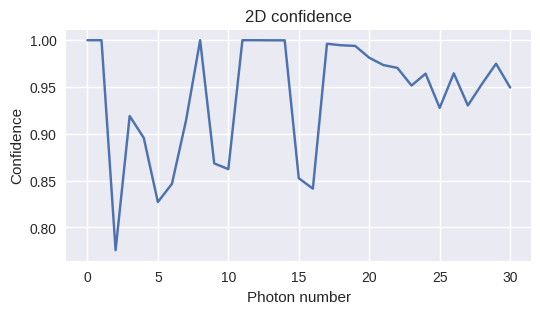

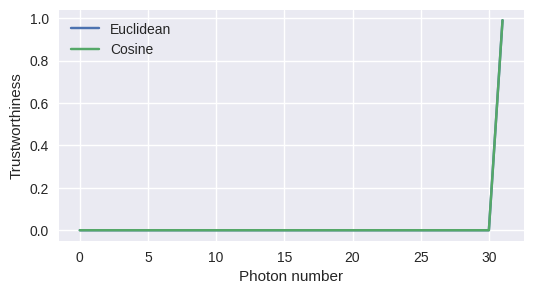

In [ ]:
#gm.plot_confidence_1d(expected_prob = expected_prob, axis = 0) 
gm.plot_confidence_2d(expected_prob = expected_prob) 
gm.plot_trustworthiness()
save_results(gm = gm, name_method = name_method, path = path_results)

### Non-Negative Matrix Factorization (NMF)

In [ ]:
X_l_NMF = sklearn_available(data_train, data_test, path_save, NMF,n_components=1, max_iter=400, solver='mu', beta_loss='kullback-leibler', tol=1e-10)

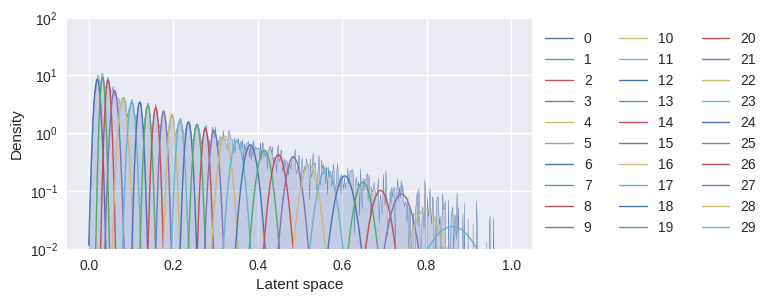

In [ ]:
name_method = 'NMF 1D'
gm = gaussian_mixture(X_low = X_l_NMF,
                      X_high = data_test,
                      number_cluster = 30,
                      cluster_iter = 5,
                      means_init = get_means(name_method, path = path_results),
                      tol = 1e-3,
                      info_sweep = 0,
                      plot_sweep = True)

gm.plot_density(bw_adjust = 0.01)
# gm.plot_cluster(plot_kde = False, bw_adjust = 0.1)
# gm.plot_traces()
# gm.plot_traces_average()

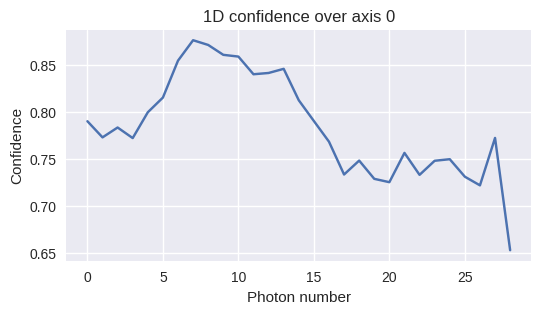

In [ ]:
gm.plot_confidence_1d(expected_prob = expected_prob, axis=0)
gm.plot_trustworthiness()
save_results(gm = gm, name_method = name_method, path = path_results)

### Isomap

In [ ]:
X_l_ISO = sklearn_available(data_train, data_test, path_save, Isomap, n_neighbors=15, n_components=1, eigen_solver="arpack")

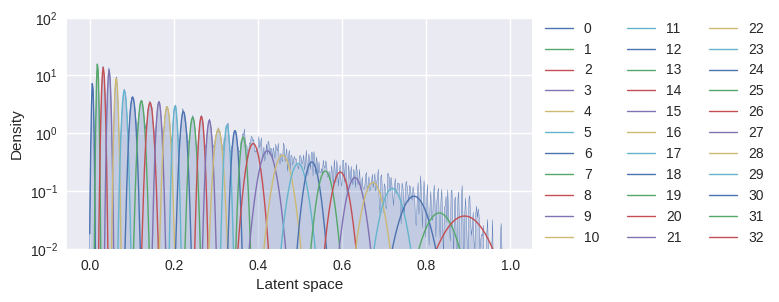

In [ ]:
name_method = 'ISO 2D'
gm = gaussian_mixture(X_low = X_l_ISO,
                      X_high = data_test,
                      number_cluster = 33,
                      cluster_iter = 5,
                      means_init = means,#get_means(name_method, path = path_results),
                      tol = 1e-5,
                      info_sweep = 0,
                      plot_sweep = True)

gm.plot_density(bw_adjust = 0.05)
#gm.plot_cluster(plot_kde = False, bw_adjust = 0.1)
#gm.plot_traces()
#gm.plot_traces_average()
#kd.plot_traces_average(data_test)

In [ ]:
gm.remove_clusters([16])

In [ ]:
means= gm.cluster_means

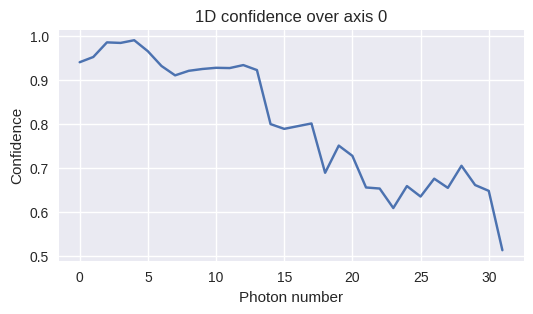

ValueError: x and y must have same first dimension, but have shapes (32,) and (33,)

In [ ]:
gm.plot_confidence_1d(expected_prob = expected_prob, axis=0)
gm.plot_trustworthiness()
save_results(gm = gm, name_method = name_method, path = path_results)

### Autoencoder



In [ ]:
path_model = '/home/nicolasdc/files/Photon-Number-Classification/src/AutoencoderLog/grid-search-TES 2D CNN 8/run 18/fold 1'#grid-search-TES 2D CNN 4/run 2/fold 0'
X_i_AUTO, X_r_AUTO, X_l_AUTO = load_autoencoder(data_test, f'{path_model}', filter=False, flip=True) #17, 18, 19, 34-2
X_l_AUTO.shape

In [ ]:
plot_traces(X_r_AUTO)

In [ ]:
name_method = 'Autoencoder'
gm = gaussian_mixture(X_l_AUTO,
                      data_test,
                      number_cluster = 27,
                      cluster_iter = 1,
                      #means_init = get_means(name_method),
                      tol = 1e-4,
                      info_sweep = 0,
                      plot_sweep = True)

gm.plot_density(bw_adjust = 0.1,
                bw_adjust_x = 0.05,
                bw_adjust_y = 0.05)
gm.plot_cluster(plot_kde = True, bw_adjust = 0.1)
#gm.plot_traces()
#gm.plot_traces_average()

In [ ]:
gm.plot_confidence_1d(expected_prob = expected_prob, axis = 0) 
gm.plot_confidence_2d(expected_prob = expected_prob)
gm.plot_trustworthiness()
#save_results(gm = gm, name_method = name_method)

In [ ]:
X_i_AUTOF, X_r_AUTOF, X_l_AUTOF = loadAutoencoder(np.copy(X_test), f'AutoencoderLog/{path_model}', 
                                                  filter=True, 
                                                  threshold=0.003)

In [ ]:
import matplotlib.pyplot as plt


plt.figure()
plt.scatter(X_l_AUTOF[:,0],X_l_AUTOF[:,1], s=1, alpha=0.01)#, c=X_l_AREA)
plt.show()

In [ ]:
kd = gaussian_mixture(X_l_AUTO, 
                    number_cluster=18,
                    flip = True)

kd.plot_cluster()
kd.plot_psn()
kd.plot_pns()
kd.plot_confidence()

In [ ]:
plt.plot(kd.cluster_means[:14])
plt.show()

### Parametric t-SNE

In [ ]:
import os
import torch

name = 'model_TES' 

# Weights of a torch model
model_weights = os.path.join(f'runs/run 17/models/2 0.003 500.pt')#ParametricTSNE/', name) + ".pt"
loaded_model = torch.load(model_weights).to(device='cpu')

#data_train_ = torch.from_numpy(data_train).float().view(-1, 350).to(device='cuda') 
data_test_ = torch.from_numpy(data_test).float().view(-1, 350).to(device='cpu')

#data_train_ = (data_train_ - data_train_.min()) / (data_train_.max() - data_train_.min())
data_test_ = (data_test_ - data_test_.min()) / (data_test_.max() - data_test_.min())

loaded_model.eval()
with torch.no_grad():
    X_l_PTSNE, X_r_PTSNE = loaded_model(data_test_, both = True)
    X_l_PTSNE, X_r_PTSNE = X_l_PTSNE.cpu().numpy(), X_r_PTSNE.cpu().numpy()

In [ ]:
name_method = 'PTSNE'
gm = gaussian_mixture(X_low = X_l_PTSNE,
                      X_high = data_test,
                      number_cluster = 25, 
                      cluster_iter = 1,
                      means_init = None,#get_means(name_method, path = path_results),
                      tol = 1e-5,
                      info_sweep = 0,
                      plot_sweep = True )

gm.plot_density(bw_adjust = 0.01,#22,
                bw_adjust_x = 0.05,
                bw_adjust_y = 0.05)
gm.plot_cluster(plot_kde = False, bw_adjust = 0.1)
gm.plot_traces()
gm.plot_traces_average()

In [ ]:
gm.plot_confidence_2d()
gm.plot_trustworthiness()
save_results(gm = gm, name_method = name_method, path = path_results)